In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, GRU, TextVectorization, Embedding

In [2]:
df = pd.read_csv('/content/drive/MyDrive/rnn_spam_sms/spam.csv', encoding='latin-1')
df = df[['v1','v2']]
df.columns = ['labels', 'text']
df.head()

,labels,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df['labels'] = df['labels'].map({'ham': 0, 'spam': 1})

In [4]:
text = np.array(df['text'])
labels = np.array(df['labels'])
len(text), len(labels)

(5572, 5572)

In [5]:
labels

array([0, 0, 1, ..., 0, 0, 0])

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(text, labels, test_size=0.2, random_state=23)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4457,), (4457,), (1115,), (1115,))

In [8]:
X_train

array(['You have been selected to stay in 1 of 250 top British hotels - FOR NOTHING! Holiday Worth å£350! To Claim, Call London 02072069400. Bx 526, SW73SS',
       'Y de asking like this.', 'Sorry de i went to shop.', ...,
       "That's fine, I'll bitch at you about it later then",
       "That's one of the issues but california is okay. No snow so its manageable",
       'I am great! How are you?'], dtype=object)

In [9]:
y_train

array([1, 0, 0, ..., 0, 0, 0])

In [10]:
sentence_lengths = [len(text.split()) for text in df['text']]
mean_text = np.mean(sentence_lengths)
max_text = np.max(sentence_lengths)
min_text = np.min(sentence_lengths)

print(f'Mean text: {mean_text}'
      f'\nMax text: {max_text}'
      f'\nMin text: {min_text}'
      f'\n95%: {np.percentile(sentence_lengths, 95)}')


Mean text: 15.494436468054559
Max text: 171
Min text: 1
95%: 33.0


In [11]:
max_tokens = 10000
output_sequence_length = 35

vectorize_layer = TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=output_sequence_length
)

In [12]:
target = df['labels'].value_counts()
target

,count
labels,
0,4825
1,747


In [13]:
disbalance = target.iloc[0] / target.iloc[1]
print(f'{disbalance:.2f}')

6.46


In [14]:
class_weights = {0: 1., 1: disbalance}

In [15]:
vectorize_layer.adapt(X_train)

In [16]:
LSTM_model = Sequential([
    vectorize_layer,
    Embedding(10000, 64),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

LSTM_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy', 'recall', 'precision']
)

history = LSTM_model.fit(X_train, y_train, validation_data=(X_test, y_test), class_weight=class_weights, epochs=5)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8782 - loss: 0.5265 - precision: 0.5336 - recall: 0.8838 - val_accuracy: 0.9848 - val_loss: 0.0746 - val_precision: 0.9760 - val_recall: 0.8971
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9859 - loss: 0.1559 - precision: 0.9391 - recall: 0.9591 - val_accuracy: 0.9668 - val_loss: 0.1133 - val_precision: 0.8278 - val_recall: 0.9191
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9939 - loss: 0.0633 - precision: 0.9710 - recall: 0.9853 - val_accuracy: 0.9767 - val_loss: 0.0963 - val_precision: 0.9167 - val_recall: 0.8897
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9973 - loss: 0.0396 - precision: 0.9870 - recall: 0.9935 - val_accuracy: 0.9794 - val_loss: 0.1004 - val_precision: 0.9380 - val_recall: 0.8897
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9982 - loss: 0.0371 - precision: 0.9935 - recall: 0.9935 - val_accuracy: 0.9767 - val_loss: 0.

In [19]:
loss, accuracy, recall, precision = LSTM_model.evaluate(X_test, y_test)

print(f'Loos: {loss:.2f},'
      f'\nAccuracy: {accuracy:.2f},'
      f'\nRecall: {recall:.2f},'
      f'\nPrecision: {precision:.2f}.')

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9767 - loss: 0.1203 - precision: 0.9104 - recall: 0.8971
Loos: 0.12,
Accuracy: 0.98,
Recall: 0.90,
Precision: 0.91.


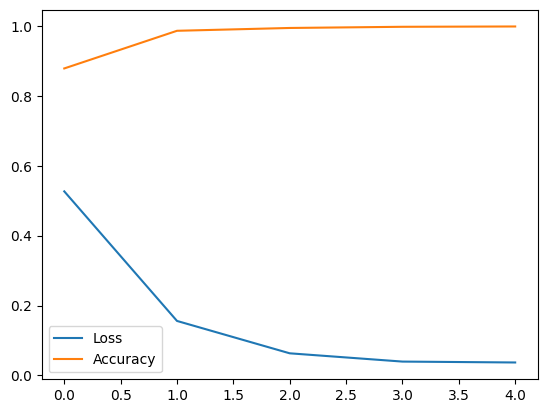

In [20]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.legend()
plt.show()

In [21]:
y_prob = LSTM_model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [22]:
y_pred = (y_prob > 0.5).astype('int')
y_pred


array([[0],
       [0],
       [1],
       ...,
       [0],
       [0],
       [0]])

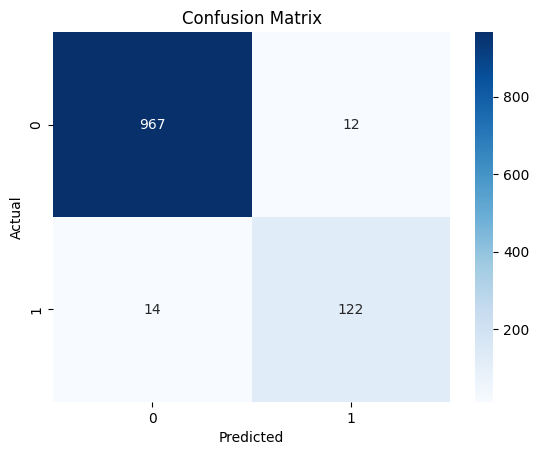

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
df_total = pd.DataFrame({
    'text': X_test,
    'labels': y_test,
    'pred': y_pred.flatten()
})

In [25]:
df_total[(df_total['labels'] == 1) & (df_total['pred'] == 0)]

,text,labels,pred
149,"Do you realize that in about 40 years, we'll h...",1,0
168,"FreeMsg Hey U, i just got 1 of these video/pic...",1,0
317,Are you unique enough? Find out from 30th Augu...,1,0
412,Guess who am I?This is the first time I create...,1,0
457,INTERFLORA - åÒIt's not too late to order Inte...,1,0
502,TBS/PERSOLVO. been chasing us since Sept forå£...,1,0
532,dating:i have had two of these. Only started a...,1,0
575,How come it takes so little time for a child w...,1,0
658,"0A$NETWORKS allow companies to bill for SMS, s...",1,0
769,Dont forget you can place as many FREE Request...,1,0


In [26]:
GRU_model = Sequential([
    vectorize_layer,
    Embedding(10000, 64),
    GRU(64),
    Dense(1, activation='sigmoid')
])

GRU_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy', 'recall', 'precision']
)

history = GRU_model.fit(X_train, y_train, validation_data=(X_test, y_test), class_weight=class_weights, epochs=7)

Epoch 1/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.5427 - loss: 0.9511 - precision: 0.2149 - recall: 0.8805 - val_accuracy: 0.9713 - val_loss: 0.1032 - val_precision: 0.9194 - val_recall: 0.8382
Epoch 2/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9832 - loss: 0.1994 - precision: 0.9268 - recall: 0.9525 - val_accuracy: 0.9668 - val_loss: 0.1430 - val_precision: 0.8113 - val_recall: 0.9485
Epoch 3/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9919 - loss: 0.0855 - precision: 0.9571 - recall: 0.9853 - val_accuracy: 0.9767 - val_loss: 0.0673 - val_precision: 0.8929 - val_recall: 0.9191
Epoch 4/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.9951 - loss: 0.0361 - precision: 0.9712 - recall: 0.9935 - val_accuracy: 0.9623 - val_loss: 0.1264 - val_precision: 0.8013 - val_recall: 0.9191
Epoch 5/7
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9984 - loss: 0.0213 - precision: 0.9919 - recall: 0.9967 - val_accuracy: 0.9722 - val_loss:

In [28]:
loss, accuracy, recall, precision = GRU_model.evaluate(X_test, y_test)

print(f'Loos: {loss:.2f},'
      f'\nAccuracy: {accuracy:.2f},'
      f'\nRecall: {recall:.2f},'
      f'\nPrecision: {precision:.2f}.')

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9776 - loss: 0.1163 - precision: 0.9302 - recall: 0.8824
Loos: 0.12,
Accuracy: 0.98,
Recall: 0.88,
Precision: 0.93.


In [29]:
y_prob_gru = GRU_model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [30]:
y_pred_gru = (y_prob_gru > 0.5).astype('int')

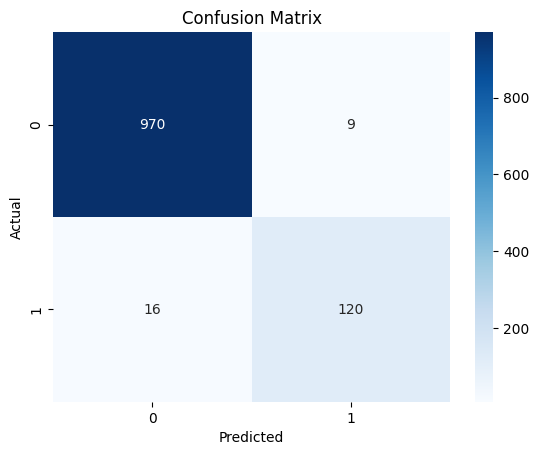

In [31]:
cm = confusion_matrix(y_test, y_pred_gru)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()